In [1]:
import numpy as np
import numpy.testing as npt
from scipy import stats
from scipy.stats import t,ttest_ind
from scipy.stats import f
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.regression._prediction import get_prediction
from statsmodels.stats.outliers_influence import OLSInfluence,MLEInfluence
from statsmodels.graphics.gofplots import qqplot_2samples,ProbPlot,qqplot
import pandas as pd
from patsy import dmatrices
from numpy.testing import assert_almost_equal, assert_allclose
import matplotlib.pyplot as plt
import seaborn as sns

# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,getRegressionEqn

# Please read nots: TRANSFORMATIONS AND WEIGHTING TO CORRECT

In [2]:
lbd = [-2,-1,-0.5,0,0.125,0.25,0.375,0.5,0.625,0.75,1,2]


In [3]:
path  = r"C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\Notes\mlx\stat_analysis\Ch-5-TRANSFORMATIONS_AND_WEIGHTING_TO_CORRECT\DataSet\DemandEnergyTbl_5_2.txt"
df = pd.read_csv(path)
print(df.columns)
need_to_transform = df['y_kW']

Index(['Customer', 'x_kWh', 'y_kW'], dtype='object')


In [4]:

# Getting lamdas value using box cox

tableDispFormatt('Get lambda value using boxcox()')
Transformed,lamda = stats.boxcox(need_to_transform)
print(lamda)
#print(Transformed)

=============================== Get lambda value using boxcox() ============================
0.2773025071596148


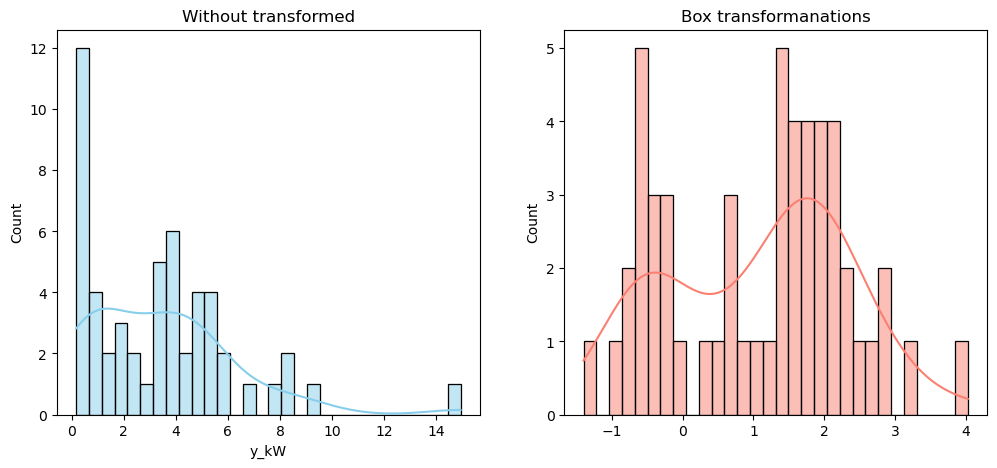

In [5]:
# Compare distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['y_kW'], bins=30,kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Without transformed')

sns.histplot(x=Transformed, bins=30,kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Box transformanations')


plt.show()


In [6]:
X = sm.add_constant(df['x_kWh'])
y = df['y_kW']
res = sm.OLS(y, X).fit()
print(res.params)
print(f"[without transformed ] Mean squared error of the residuals {res.mse_resid}")
resid_without_trasformed = res.resid

const   -0.831304
x_kWh    0.003683
dtype: float64
[without transformed ] Mean squared error of the residuals 2.48756898893957


In [7]:
# update y with Box cox transformanations
y = Transformed
res = sm.OLS(y, X).fit()
print(res.params)
print(f"[Box-Cox transformed ] Mean squared error of the residuals {res.mse_resid}")
boxcox_trasformanations = res.resid

const   -0.660572
x_kWh    0.001500
dtype: float64
[Box-Cox transformed ] Mean squared error of the residuals 0.6579556112899694


you can see Mean sqaure error with transformed  = 2.48756898893957 &

after trasfromanations  0.6579556112899694. Drametically redused.

Text(0.5, 1.0, 'Q-Q Plot: Box-Cox transformanations')

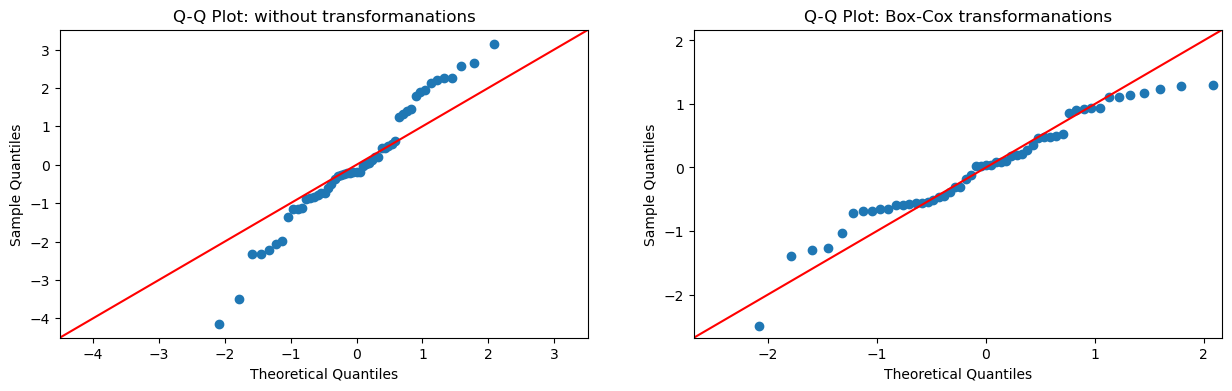

In [8]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 4))


# Q-Q plots
sm.qqplot(resid_without_trasformed, line='45', ax=axes[0])
axes[0].set_title('Q-Q Plot: without transformanations')

# Q-Q plots
sm.qqplot(boxcox_trasformanations, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot: Box-Cox transformanations')


TODO:

- Required more asnalysis
- Do BoxCox with manually
  - take lambda = [-2,-1,-0.5,0,0.125,0.25,0.375,0.5,0.625,0.75,1,2]
  - apply box Cox trasformanations on above lambda
  - Calculate SSres for diffresnt value of lambda
  - Finally calculate Min SSres for lambda. [See you nots]